In [2]:
import duckdb
import pandas as pd

## Load/prep data

In [3]:
# connect to db

conn = duckdb.connect("../bluesky.duckdb")

In [4]:
import duckdb

'''
Reads in 4 data files and creates tables in duckdb for them.
- posts
- accounts
- post_features
- account_features
'''

conn = duckdb.connect("social_bots.duckdb")

conn.execute("""
CREATE OR REPLACE TABLE posts AS
SELECT * FROM read_parquet('../data/posts.parquet')
""")

conn.execute("""
CREATE OR REPLACE TABLE accounts AS
SELECT * FROM read_parquet('../data/accounts.parquet')
""")

conn.execute("""
CREATE OR REPLACE TABLE post_features AS
SELECT * FROM read_parquet('../data/post_features.parquet')
""")

conn.execute("""
CREATE OR REPLACE TABLE account_features AS
SELECT * FROM read_parquet('../data/account_features.parquet')
""")

In [5]:
# visualize joined data 

joined_posts = conn.execute("""
SELECT
    p.id,
    p.did,
    p.text,
    pf.char_count,
    pf.word_count,
    pf.has_url,
    pf.has_hashtag,
    pf.has_mention,
    pf.is_reply
FROM posts p
JOIN post_features pf
    ON p.id = pf.post_id
LIMIT 10
""").df()

joined_posts

,id,did,text,char_count,word_count,has_url,has_hashtag,has_mention,is_reply
0,at://did:plc:lejpu7zrbsegoi75wpvm2sch/app.bsky...,did:plc:lejpu7zrbsegoi75wpvm2sch,American Idol 2026 Top 14 Revealed! Some big n...,180,27,0,0,0,False
1,at://did:plc:b5wp4fgce22ixrggskz3kwk6/app.bsky...,did:plc:b5wp4fgce22ixrggskz3kwk6,オムライス,5,1,0,0,0,False
2,at://did:plc:27uvdj4hkoxksgqs737uiyrp/app.bsky...,did:plc:27uvdj4hkoxksgqs737uiyrp,よし。本丸録届いたぽい（イン会社）,17,1,0,0,0,False
3,at://did:plc:fj2d6rwtqgkzz77iocgcuwk4/app.bsky...,did:plc:fj2d6rwtqgkzz77iocgcuwk4,everyday hormuz stays closed thats 20mbpd not ...,137,22,0,0,0,True
4,at://did:plc:nr3sk72qhacjuihqyy6sfplv/app.bsky...,did:plc:nr3sk72qhacjuihqyy6sfplv,realest shit i ever read on the internet right...,51,10,0,0,0,True
5,at://did:plc:2ow4s6cci5ylwwdedvx3qtkx/app.bsky...,did:plc:2ow4s6cci5ylwwdedvx3qtkx,LLMエージェント対応を強化した ecspresso v2.8 をリリースしました - 酒日...,107,7,1,0,0,False
6,at://did:plc:ndjyym3ihrqu3g25gdztefrv/app.bsky...,did:plc:ndjyym3ihrqu3g25gdztefrv,EFTA02183826.jpg\n#epsteinweb #efta02183826\nh...,156,8,1,1,0,False
7,at://did:plc:c7ocgtuam5t56eb72y7d4hnu/app.bsky...,did:plc:c7ocgtuam5t56eb72y7d4hnu,Can you read the article I posted with a link...,99,22,0,0,0,True
8,at://did:plc:saxpogspfysemxo4sl3nnpgb/app.bsky...,did:plc:saxpogspfysemxo4sl3nnpgb,Reviewer? You're supposed to be a comedy provi...,50,8,0,0,0,True
9,at://did:plc:qcwhrvzx6wmi5hz775uyi6fh/app.bsky...,did:plc:qcwhrvzx6wmi5hz775uyi6fh,I think I’m falling for you...///,33,6,0,0,0,True


In [6]:
df = conn.execute("""
SELECT 
    a.did,
    a.post_count,
    af.reply_rate,
    af.url_rate,
    af.hashtag_rate,
    af.mention_rate,
    af.avg_post_length,
    af.avg_word_count
FROM accounts a
JOIN account_features af
    ON a.did = af.did
""").df()

In [7]:
df.head()

,did,total_posts,reply_rate,url_rate,hashtag_rate,mention_rate,avg_post_length,avg_word_count
0,did:plc:6fi4ua55jhqdyix74q3tpbnh,1,0.0,0.000000,1.0,0.0,44.000000,6.000000
1,did:plc:fe3dmo4esdbvqi4vvkek6xjs,13,0.0,0.000000,0.0,0.0,49.846154,1.000000
2,did:plc:jgykciobnnrfzgpybaebwry6,1,1.0,0.000000,0.0,0.0,3.000000,1.000000
3,did:plc:rojjr6zef7m2xpfdt6jw5fta,7,1.0,0.142857,0.0,0.0,19.285714,3.714286
4,did:plc:owo2l6v35uvk3axlrkz6d2wt,4,0.0,0.000000,0.0,0.0,297.500000,43.250000


## 1. Supervised: Logistic regression

### Analysis Rationale 


The biggest decision was how to define bot-like accounts without ground truth data. The goal of this analysis is to identify accounts that look bot-like based on their behavior. Since I don’t have true labeled data for bots vs. humans, I created labels using simple rules based on extreme patterns in the data. I chose to label accounts using percentile-based thresholds on posting frequency and URL usage, since these showed clear heavy-tailed distributions in the EDA. This approach prioritizes identifying extreme, high-confidence cases rather than trying to classify all accounts. The tradeoff is that it likely misses more subtle bots and may incorrectly flag some high-activity human accounts.

Accounts are labeled as bots if they have very high activity and URL usage (top 5%), and labeled as human if they have very low activity and behave more conversationally (low post count but higher reply rate). This isn’t perfect ground truth, but it gives a clean way to separate clearly different types of accounts so I can train a model.

One issue with this approach is data leakage. Some of the features used to create the labels (like total posts, URL rate, and reply rate) could make the model artificially accurate if they are also used as inputs. To avoid that, I removed those features from the model so it has to learn from other signals like hashtags, mentions, and text characteristics instead.

I used logistic regression because it’s simple and easy to interpret. The coefficients make it clear which behaviors are more associated with bot-like vs human-like accounts, which is useful for explaining the results.

The high accuracy should be interpreted carefully. Because the labels are based on extreme thresholds, the model is mostly learning to separate very obvious cases rather than solving a fully realistic classification problem. So this is better thought of as detecting accounts that match a “bot-like profile” rather than definitively identifying bots.

In addition to accuracy, I also evaluated the model using precision, recall, and F1 score to get a better sense of how well it identifies bot-like accounts. Accuracy alone can be misleading, especially when the classes are imbalanced or when labels are heuristic. Precision measures how reliable the bot predictions are (how many predicted bots are actually bot-like), while recall measures how many of the bot-like accounts the model is able to detect. The F1 score balances these two and gives a more complete view of performance.

In this case, the model achieves high precision for bot-like accounts, meaning that when it flags an account as a bot, it is usually correct. Recall is slightly lower, indicating that some bot-like accounts are not being detected. This suggests the model is somewhat conservative in labeling bots, prioritizing correctness over coverage. Overall, the F1 score reflects a strong balance between these two objectives, supporting the conclusion that the model is effective at identifying clear bot-like behavior while avoiding excessive false positives.

Overall, the approach works well for demonstrating how relational data and feature engineering can be used to model behavior, while still acknowledging the limitations of the labeling strategy.

#### Preprocess/Labelling 

In [8]:
# calculate 95th percentile thresholds for total posts and url_rate
post_thresh = df['total_posts'].quantile(0.95)
url_thresh = df['url_rate'].quantile(0.95)

In [9]:
'''
label accounts as 1 if they have more than the post and url thresholds, 
otherwise label as 0 if they have 2 or fewer posts and a reply rate above 0.2, 
otherwise leave as None
'''

df["label"] = None

df.loc[
    (df["total_posts"] > post_thresh) & (df["url_rate"] > url_thresh),
    "label"
] = 1

df.loc[
    (df["total_posts"] <= 2) & (df["reply_rate"] > 0.2),
    "label"
] = 0

In [10]:
# sanity check label distribution
df["label"].value_counts(dropna=False)

label
None    27699
0       15083
1         161
Name: count, dtype: int64

In [11]:
# drop unlabeled accounts and balance classes by randomly sampling from the majority class (humans)
df_labeled = df.dropna(subset=["label"])

bots = df_labeled[df_labeled["label"] == 1]
humans = df_labeled[df_labeled["label"] == 0].sample(len(bots), random_state=42)

df_balanced = pd.concat([bots, humans])

#### Training model (logistic regression)

In [12]:
df_labeled = df.dropna(subset=["label"]).copy()
df_labeled["label"] = df_labeled["label"].astype(int)

bots = df_labeled[df_labeled["label"] == 1]
humans = df_labeled[df_labeled["label"] == 0].sample(len(bots), random_state=42)

df_balanced = pd.concat([bots, humans]).sample(frac=1, random_state=42)

X = df_balanced.drop(columns=["did", "label", "total_posts", "url_rate", "reply_rate"]) # drop columns used to derive labels
y = df_balanced["label"].astype(int)

In [13]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
# train model (logistic regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Evaluate model

In [15]:
# accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8461538461538461


In [17]:
# precision, recall, f1 score for bot class
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1 Score:", round(f1, 2))

Precision: 0.94
Recall: 0.78
F1 Score: 0.85


#### Visualize Results

This visualization displays the coefficients from the logistic regression model used to distinguish between likely human-generated and AI-generated posts. I selected a horizontal bar chart because it communicates both the **direction** and **magnitude** of each feature's influence on the model's predictions.

Features are sorted by coefficient value to emphasize relative importance. This makes it easy to identify which characteristics are most strongly associated with bot-like or human-like behavior. I placed a vertical reference line at zero to separate positive and negative contributions, helping to quickly interpret whether a feature increases or decreases the likelihood of a post being classified as AI-generated.

Text labels are placed directly on the bars to improve readability and eliminate the need for viewers to estimate values from the axis. I rewrote the feature names as more interpretable plain english labels. 

The title is written in a narrative style to highlight the primary insight for a non-technical audience, while the subtitle provides additional context about how to interpret the coefficients.

In [39]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(coef)

avg_word_count    -0.583938
avg_post_length    0.101799
mention_rate       0.179915
hashtag_rate       1.836032
dtype: float64


In [40]:
import matplotlib.pyplot as plt

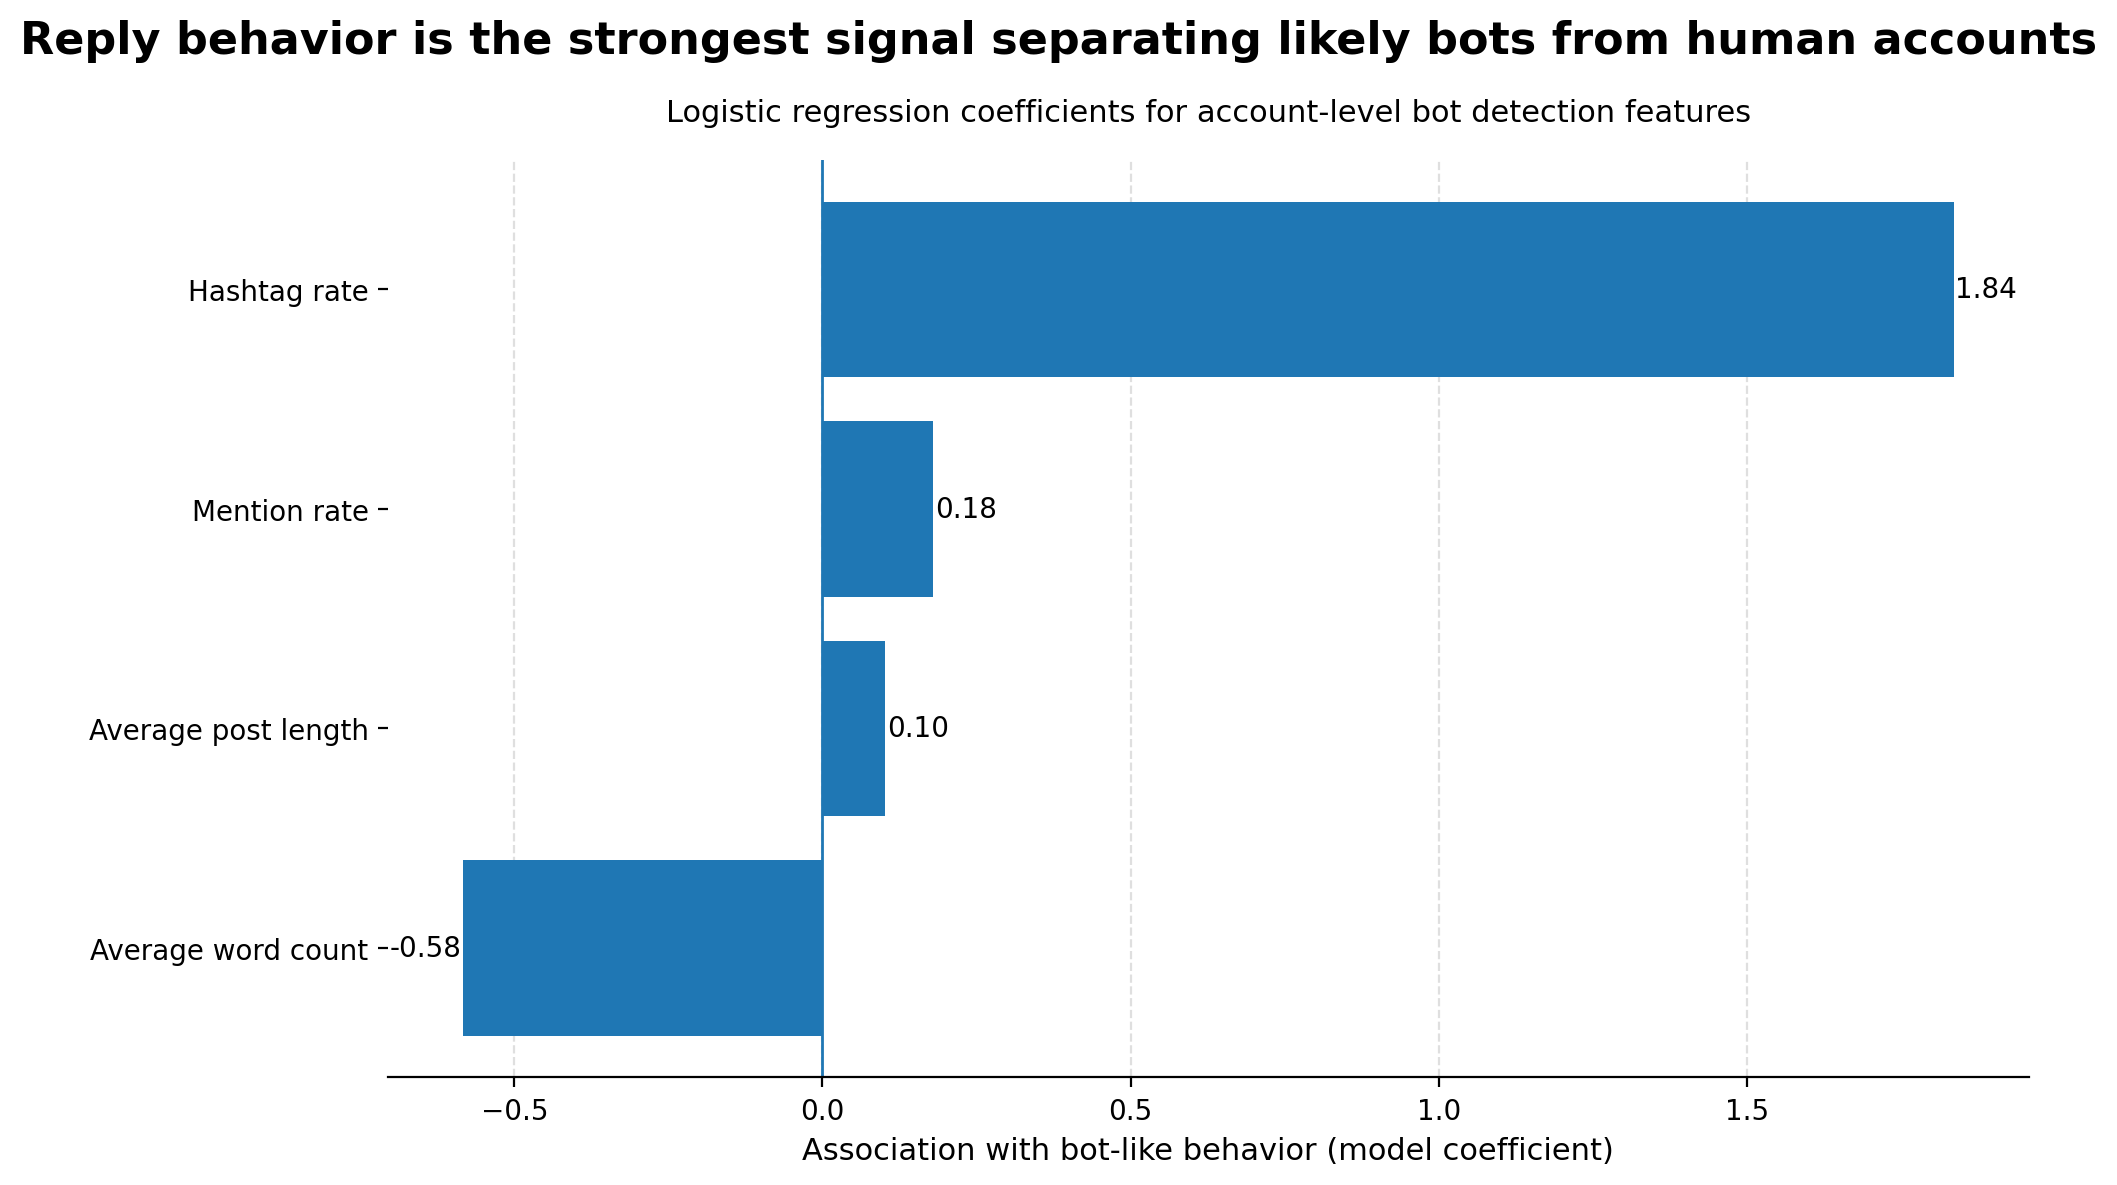

In [41]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

pretty_names = {
    "hashtag_rate": "Hashtag rate",
    "avg_post_length": "Average post length",
    "mention_rate": "Mention rate",
    "avg_word_count": "Average word count",
    "reply_rate": "Reply rate"
}
coef.index = [pretty_names.get(i, i) for i in coef.index]

bars = ax.barh(coef.index, coef.values)

# Zero line
ax.axvline(0, linewidth=1)

# Direct labels on bars
x_pad = (coef.max() - coef.min()) * 0.001
for bar, val in zip(bars, coef.values):
    y = bar.get_y() + bar.get_height() / 2
    if val >= 0:
        ax.text(val + x_pad, y, f"{val:.2f}", va="center", ha="left", fontsize=10)
    else:
        ax.text(val - x_pad, y, f"{val:.2f}", va="center", ha="right", fontsize=10)

# Titles
fig.suptitle(
    "Reply behavior is the strongest signal separating likely bots from human accounts",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

ax.set_title(
    "Logistic regression coefficients for account-level bot detection features",
    fontsize=11,
    pad=14
)

# Axis labels
ax.set_xlabel("Association with bot-like behavior (model coefficient)", fontsize=11)
ax.set_ylabel("")

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Light x-grid only
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Tick styling
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

In [42]:
# Get "bot" DIDs
bot_dids = df_balanced[df_balanced["label"] == 1]["did"]

In [43]:
# query posts
bot_posts = conn.execute("""
SELECT did, text
FROM posts
WHERE did IN (
    SELECT did FROM account_features
    WHERE did IN ({})
)
LIMIT 50
""".format(",".join([f"'{d}'" for d in bot_dids[:20]]))).df()

In [44]:
for i, row in bot_posts.head(10).iterrows():
    print("\n---")
    print(row["text"])


---
FIFA Series 2026: Indonesia takluk dari Bulgaria - https://www.antaranews.com/infografik/5502274/fifa-series-2026-indonesia-takluk-dari-bulgaria

---
Pagelaran Tari Wulang Sunu massal - https://www.antaranews.com/foto/5502306/pagelaran-tari-wulang-sunu-massal

---
PSIM Yogyakarta bidik hasil positif pada sembilan laga tersisa - https://www.antaranews.com/berita/5502302/psim-yogyakarta-bidik-hasil-positif-pada-sembilan-laga-tersisa

---
www.youtube.com/watch?v=m5Vd...

---
www.nytimes.com/2026/03/30/u...

---
www.nytimes.com/2026/03/30/u...

---
www.youtube.com/watch?v=_5Rt...

---
To move here, you have to tolerate WIND, and not just a little wind!

I'm talking...blow semis over wind. 

cowboystatedaily.com/2026/03/29/a...

---
www.youtube.com/watch?v=4NFX...

---
RT @jwave813fm: 【J-WAVE BAR vol.29 #秦基博 にご招待🍷】

J-WAVE局内に不定期でオープンする「J-WAVE BAR」🌃

今回は、秦基博が登場✨

音楽と共にお酒と東京の夜景を堪能できる
極上のライブにJ-me会員15名様ご招待します🍸…


## 2. Unsupervised: PCA


#### Analysis Rationale

I used PCA to get a quick sense of whether the features I engineered actually separate accounts in a meaningful way. Since the original feature space is higher-dimensional, PCA lets me project everything down to two dimensions so I can visualize the structure.

The goal here wasn’t to build a model, but to sanity check the data. If the labels I created (bot vs human) are capturing real differences in behavior, then I should see at least some separation in this reduced space.

The plot shows that bot-like and human-like accounts tend to cluster in different regions, but with noticeable overlap. As expected, the problem is not perfectly separable, and some accounts behave in ways that are not clearly one or the other, which makes the classification task more realistic.

This step helps confirm that the features are capturing useful behavioral patterns, while also showing that the model has to deal with some ambiguity rather than just learning a trivial separation.

#### PCA visualization

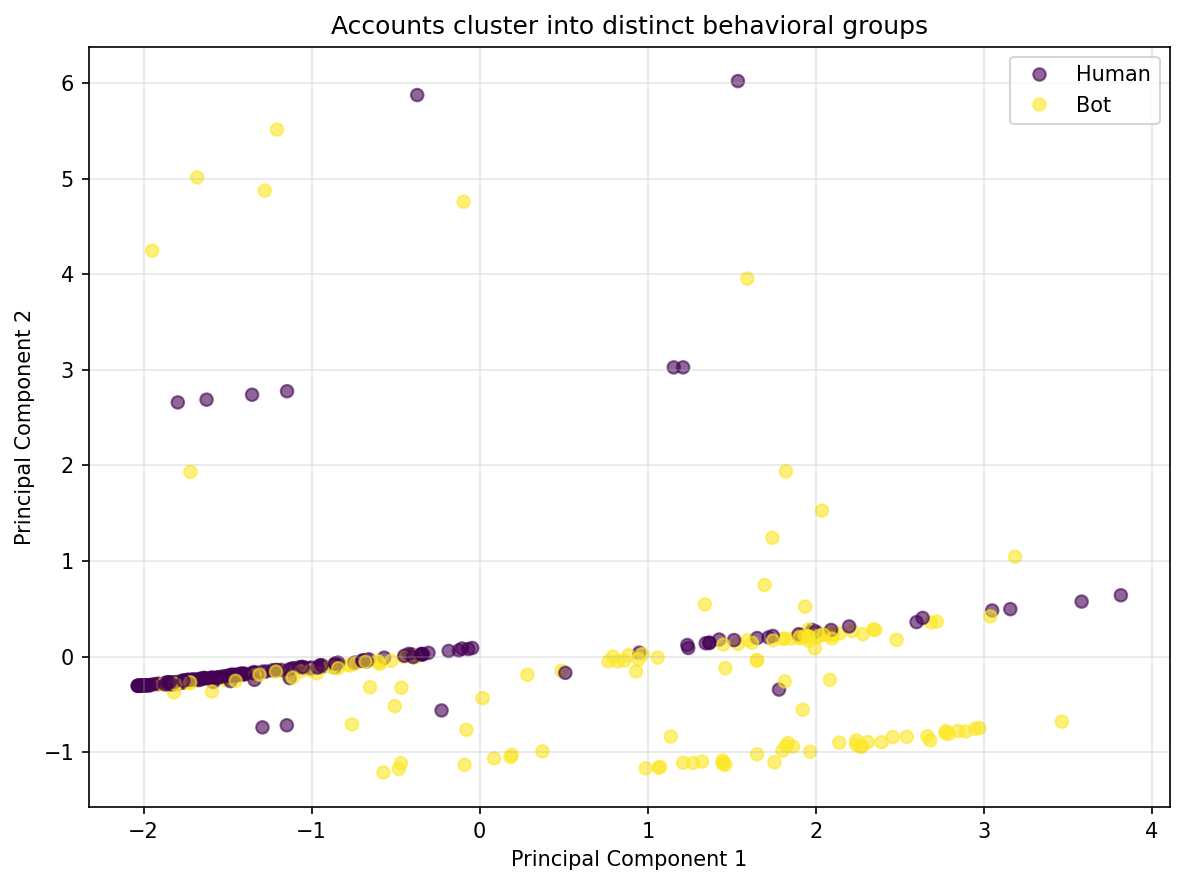

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# labels
y_plot = df_balanced["label"]

# features: match exactly what you used for modeling
X_plot = df_balanced.drop(columns=["did", "label", "total_posts", "url_rate", "reply_rate"])

# scale
X_scaled = StandardScaler().fit_transform(X_plot)

# PCA
X_reduced = PCA(n_components=2).fit_transform(X_scaled)

# plot
plt.figure(figsize=(8, 6), dpi=150)
scatter = plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y_plot,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Accounts cluster into behavioral groups")
plt.legend(handles=scatter.legend_elements()[0], labels=["Human", "Bot"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

While there is overlap between groups, the visualization shows that accounts labeled as bots tend to occupy different regions of the feature space, indicating that the engineered features capture meaningful behavioral patterns.